# Cohort FACTM — synthetic experiments

Four experiments on synthetic data to validate inter-cohort variability detection.

**Exp 0 — Null test.** No cohort differences exist; the model must not invent any (gamma stays near the prior pi).

**Exp 1 — Single active factor.** One factor has an asymmetric cohort offset (one cohort shifted, one at zero). Tests signal localization and verifies that Hungarian matching correctly recovers which cohort carries the shift.

**Exp 2 — Full cohort profiles.** Each of C=4 cohorts has a distinct mean vector mu_c across K=3 factors. Tests whether E[gamma*delta] rows match the true mu rows.

**Exp 3 — Cohort distance structure.** Pairwise L2 distances between cohort mean vectors should be preserved in the fitted latent space.

**Exp 4 — Signal scale effect.** Stronger inter-cohort separation (larger mu) should yield better distance recovery.

Hungarian algorithm is used throughout to align estimated factors with ground-truth factors before computing metrics.

### Imports

In [25]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views

### Helpers: data generation, model fitting, Hungarian matching

In [26]:
def generate_data(mu_ck, sigma, n_per_cohort, dims=(15, 15), noise=1.0, seed=0):
    """Generate synthetic cohort data: Z ~ N(mu_ck[c], sigma), Y_m = Z W_m^T + noise."""
    rng = np.random.default_rng(seed)
    C, K = mu_ck.shape
    codes = np.repeat(np.arange(C), n_per_cohort)
    Z = np.array([rng.normal(mu_ck[c], sigma) for c in codes])
    Ys = [Z @ rng.normal(size=(d, K)).T + rng.normal(scale=noise, size=(Z.shape[0], d)) for d in dims]
    return Views.from_list(Ys, cohorts=np.array([f'c{c}' for c in codes])), Z, codes


def fit_cohort(views, K, pi=0.5, max_iter=100, seed=0):
    """Fit CohortFACTM with spike-and-slab cohort prior (ZPrior.COHORT)."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=100, seed=0):
    """Fit standard FACTM with isotropic N(0,1) prior — no cohort structure."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def hungarian(Z_true, Z_hat):
    """Match estimated factors to ground-truth by maximising sum of |corr|.

    Returns perm and signs so that Z_hat[:, perm] * signs ~= Z_true.
    Uses mean-centred Pearson correlation — robust to asymmetric factor means.
    """
    K = Z_true.shape[1]
    corr = np.array([[np.corrcoef(Z_true[:, i], Z_hat[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col])
    signs[signs == 0] = 1
    return col, signs.astype(float)


def evaluate(model, Z_true, K):
    """Hungarian-align then compute per-factor |corr|, E[gamma], E[delta] (sign-corrected)."""
    Zh = model.get_latent_factors()
    perm, signs = hungarian(Z_true, Zh)
    matched = np.array([
        abs(np.corrcoef(Z_true[:, k], Zh[:, perm[k]] * signs[k])[0, 1])
        for k in range(K)
    ])
    is_cohort = model.fa.node_z.z_priors[0].__class__.__name__ == 'CohortZPrior'
    if is_cohort:
        priors = model.fa.node_z.z_priors
        E_g = np.column_stack([priors[k].E_gamma for k in range(K)])[:, perm]
        E_d = np.column_stack([priors[k].E_delta for k in range(K)])[:, perm] * signs[None, :]
    else:
        E_g = E_d = None
    return {'corr': matched, 'E_gamma': E_g, 'E_delta': E_d,
            'elbo': float(model.elbo_sequence[-1])}

## Experiment 0 — Null test: no cohort differences

**Goal:** Verify that the spike-and-slab prior does not invent cohort structure when none
exists. This is the most fundamental sanity check: a correctly specified model should
suppress gamma when cohorts are exchangeable.

**Setup:** C=2 cohorts, K=2 factors, mu=0 for all cohorts — both cohorts are drawn from
the same N(0, 1) distribution. Prior pi=0.2 (conservative).

**Expected:**
- E[gamma] near pi=0.2 for every factor x cohort cell (no systematic activation).
- ELBO of the cohort model approximately equals ELBO of the baseline.
- E[delta] near 0 everywhere.

In [27]:
# Null test: both cohorts share the same latent distribution (mu=0 for all cohorts).
mu_0 = np.zeros((2, 2))
views_0, Z_0, _ = generate_data(mu_0, sigma=1.0, n_per_cohort=100, seed=42)

m0_c = fit_cohort(views_0, K=2, pi=0.2)
m0_b = fit_baseline(views_0, K=2)
out_0 = evaluate(m0_c, Z_0, K=2)

tab0 = pd.DataFrame({
    'mean E[gamma]': out_0['E_gamma'].mean(axis=0).round(3),
    'max|E[delta]|': np.abs(out_0['E_delta']).max(axis=0).round(3),
}, index=['Z0', 'Z1'])
print("Null test — E[gamma] should stay near 0.2 (the prior pi); E[delta] near 0:")
print(tab0.to_string())
print(f"\nELBO  cohort = {out_0['elbo']:.1f},  baseline = {float(m0_b.elbo_sequence[-1]):.1f}")

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 82.89it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 93.01it/s]

Null test — E[gamma] should stay near 0.2 (the prior pi); E[delta] near 0:
    mean E[gamma]  max|E[delta]|
Z0            0.0            0.0
Z1            0.0            0.0

ELBO  cohort = -9778.8,  baseline = -9761.1


## Experiment 1 — Signal localization: one asymmetrically shifted factor

**Goal:** Verify that gamma activates only on the factor with a genuine cohort offset, and
that Hungarian matching correctly recovers *which* cohort carries the shift.

**Setup:** C=2 cohorts, K=3 factors, sigma=0.5, N=100 per cohort.
- Z0: c0 has offset +2.5, c1 has offset 0 (asymmetric — mimics a case-vs-control design).
- Z1, Z2: both cohorts share the same distribution — no cohort difference.

**Expected:**
- E[gamma] near 1 for c0 on Z0; near 0 on Z1 and Z2.
- After sign-corrected Hungarian matching: E[delta] for c0 on Z0 is large and positive;
  E[delta] for c1 on Z0 is near 0.
- Cohort ELBO > baseline ELBO.

**Note on Hungarian and asymmetric signals:** Hungarian uses mean-centred Pearson
correlation, so it correctly identifies the active factor even though Z0 has a non-zero
global mean (~1.25 for equal cohort sizes). The sign correction in evaluate() then ensures
E[delta] points toward the shifted cohort, preserving information about *which* cohort is
elevated.

In [33]:
# Asymmetric signal: c0 is shifted +2.5 on Z0; c1 is the control (no offset).
# All other factors are pure noise with no cohort structure.
mu_1 = np.array([[ .8, 0., 0.],   # c0: offset on Z0
                  [ 0,  0., 0.]])  # c1: no offset (control)
views_1, Z_1, codes_1 = generate_data(mu_1, sigma=0.5, n_per_cohort=100, seed=0)

m1_c = fit_cohort(views_1, K=3, pi=0.5)
m1_b = fit_baseline(views_1, K=3)
out_c = evaluate(m1_c, Z_1, K=3)
out_b = evaluate(m1_b, Z_1, K=3)

# Per-factor summary. After Hungarian, row 'Z0' corresponds to true Z0 (the factor with
# cohort signal), so true_max|mu| = 2.5 is correct.
tab1 = pd.DataFrame({
    'true_active':     [True, False, False],
    'true_max|mu|':    [2.5, 0.0, 0.0],
    '|corr|_cohort':   out_c['corr'].round(3),
    '|corr|_baseline': out_b['corr'].round(3),
    'mean E[gamma]':   out_c['E_gamma'].mean(axis=0).round(3),
    'max|E[delta]|':   np.abs(out_c['E_delta']).max(axis=0).round(3),
}, index=['Z0', 'Z1', 'Z2'])
print(tab1.to_string())
print(f"\nELBO  cohort = {out_c['elbo']:.1f},  baseline = {out_b['elbo']:.1f}")

# Hungarian diagnostic — per-cohort E[delta] and E[gamma] for the matched Z0 factor.
# c0 (shifted) should show large E[delta] and E[gamma]~1; c1 (control) near 0.
# This confirms sign-corrected Hungarian preserves which cohort carries the signal.
print("\nHungarian diagnostic — per-cohort values for matched Z0:")
for c, label in enumerate(['c0 (shifted, true delta=+2.5)', 'c1 (control, true delta=0)']):
    print(f"  {label}: E[gamma] = {out_c['E_gamma'][c, 0]:.3f},  E[delta] = {out_c['E_delta'][c, 0]:.3f}")

Pretraining FA
Fitting model


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 54.44it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 65.30it/s]

    true_active  true_max|mu|  |corr|_cohort  |corr|_baseline  mean E[gamma]  max|E[delta]|
Z0         True           2.5          0.835            0.889          1.000          0.324
Z1        False           0.0          0.722            0.825          0.000          0.000
Z2        False           0.0          0.557            0.776          0.999          0.241

ELBO  cohort = -9756.4,  baseline = -9762.0

Hungarian diagnostic — per-cohort values for matched Z0:
  c0 (shifted, true delta=+2.5): E[gamma] = 1.000,  E[delta] = 0.323
  c1 (control, true delta=0): E[gamma] = 1.000,  E[delta] = -0.324


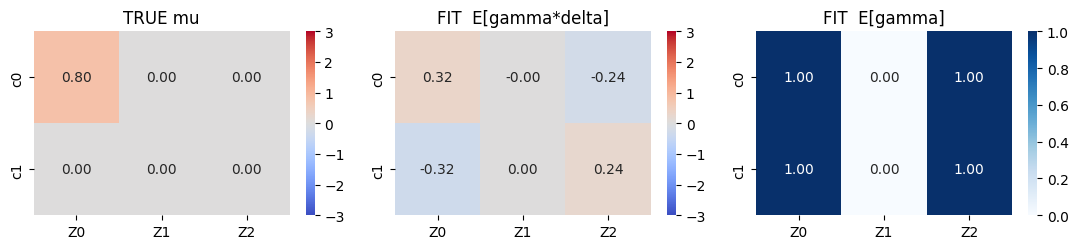

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
sns.heatmap(mu_1, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[0])
axes[0].set_title('TRUE mu')
sns.heatmap(out_c['E_gamma'] * out_c['E_delta'], annot=True, fmt='.2f',
             cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[1])
axes[1].set_title('FIT  E[gamma*delta]')
sns.heatmap(out_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[2])
axes[2].set_title('FIT  E[gamma]')
plt.tight_layout()
plt.show()

## Experiment 2 — Full cohort profiles across multiple factors

**Goal:** Verify that the model recovers each cohort's full mean vector. If every cohort
has a distinct profile mu_c across K factors, the fitted rows E[gamma*delta] should
correlate strongly with the corresponding true rows.

**Setup:** C=4 cohorts, K=3 factors, sigma=0.8, N=80 per cohort.
- Z0: gradient (2, 1, -1, -2) across cohorts.
- Z1: single shift on c1 only (0, 2, 0, 0).
- Z2: alternating signs (1.5, -1.5, 1.5, -1.5).

**Metrics:** Per-cohort Pearson correlation and MAE between true mu row and fitted E[gamma*delta] row.

**Expected:** row_corr > 0.8 and MAE < 1.0 for each cohort; heatmaps show visually
similar colour patterns.

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:02<00:00, 48.11it/s]


cohort  row_corr  row_mae
    c0     0.788    0.562
    c1     0.800    0.681
    c2       NaN    0.065
    c3     0.306    1.283


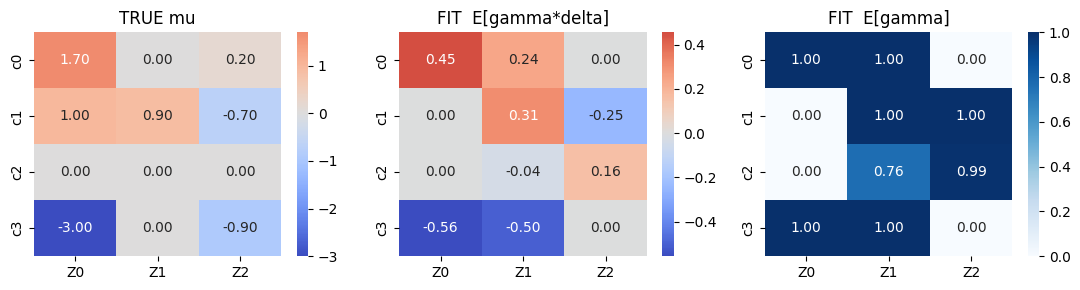

In [30]:
C = 4
K = 3
mu = np.array([
    [ 1.7, 0.0,  .2],
    [ 1.0, .9, -.7],
    [.0, 0.0,  0.],
    [-3.0, 0.0, -.9],
])
views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[120] * C, seed=3)
m = fit_cohort(views, K=K, pi=0.3, seed=3)
out = evaluate(m, Z, K=K)

mu_fit = out['E_gamma'] * out['E_delta']
rows = []
for c in range(C):
    corr = float(np.corrcoef(mu[c], mu_fit[c])[0, 1])
    mae = float(np.mean(np.abs(mu[c] - mu_fit[c])))
    rows.append({'cohort': f'c{c}', 'row_corr': corr, 'row_mae': mae})
df_rows = pd.DataFrame(rows)
print(df_rows.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
sns.heatmap(mu, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[0])
axes[0].set_title('TRUE mu')
sns.heatmap(mu_fit, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[1])
axes[1].set_title('FIT  E[gamma*delta]')
sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[2])
axes[2].set_title('FIT  E[gamma]')
plt.tight_layout()
plt.show()

## Experiment 3 — Cohort distance structure

**Goal:** Verify that pairwise L2 distances between cohort mean vectors are preserved in
the fitted latent space. If the model correctly captures inter-cohort variability, the
distance matrix computed from E[gamma*delta] should correlate strongly with the true
distance matrix computed from mu.

**Setup:** C=5 cohorts, K=3 factors, sigma=0.8, N=70 per cohort. Cohorts span a gradient
in factor space.

**Metric:** Pearson correlation between upper-triangle entries of the true and fitted
distance matrices.

**Expected:** distance_corr > 0.9; the two heatmaps should have the same ordering of
nearby vs distant cohort pairs.

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:02<00:00, 48.54it/s]


distance corr (upper triangle) = 0.974


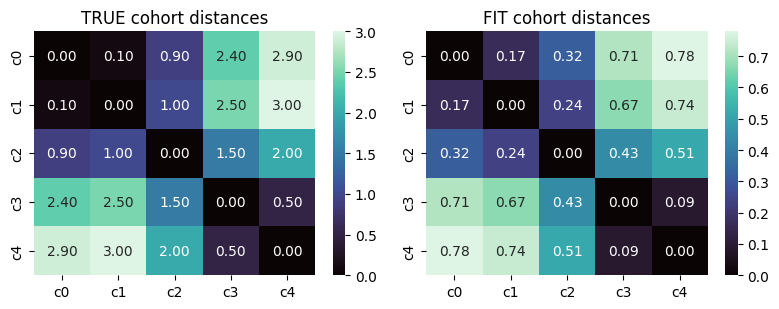

In [31]:
C = 5
K = 3
mu = np.array([
    [ .9,  0.0, 0.0],
    [ 1.0,  0.0, 0.0],
    [ 0.0,  0.0, 0.0],
    [-1.5, -0.0, 0.0],
    [-2.0, -0.0, 0.0],
])
views, Z, _ = generate_data(mu, sigma=1.2, n_per_cohort=[120] * C, seed=4)
m = fit_cohort(views, K=K, pi=0.3, seed=4)
out = evaluate(m, Z, K=K)
mu_fit = out['E_gamma'] * out['E_delta']


def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


D_true = cohort_dist(mu)
D_fit = cohort_dist(mu_fit)
tri = np.triu_indices(C, 1)
dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
print(f"distance corr (upper triangle) = {dist_corr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
sns.heatmap(D_true, annot=True, fmt='.2f', cmap='mako',
            xticklabels=[f'c{c}' for c in range(C)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[0])
axes[0].set_title('TRUE cohort distances')
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=[f'c{c}' for c in range(C)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[1])
axes[1].set_title('FIT cohort distances')
plt.tight_layout()
plt.show()

## Experiment 4 — Effect of signal scale on distance recovery

**Goal:** Show that stronger inter-cohort separation (larger mu) leads to better recovery
of the cohort distance structure. This tests whether the model benefits from clearer
variability between cohorts.

**Setup:** Base mu from Experiment 3, scaled by s in {0.5, 1.0, 2.0}. All other settings
fixed (C=5, K=3, sigma=0.8, N=70).

**Expected:** distance_corr increases monotonically with s — larger cohort offsets are
easier to detect and recover.

In [32]:
C = 5
K = 3
base_mu = np.array([
    [ 2.0,  1.0, 0.0],
    [ 1.0,  1.0, 2.0],
    [ 0.0,  1.0, 0.0],
    [-1.0, -1.0, 0.0],
    [-2.0, -1.0, 0.0],
])
scales = [0.5, 1.0, 2.0]


def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


rows = []
for s in scales:
    mu = s * base_mu
    views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[70] * C, seed=5)
    m = fit_cohort(views, K=K, pi=0.3, seed=5)
    out = evaluate(m, Z, K=K)
    mu_fit = out['E_gamma'] * out['E_delta']
    D_true = cohort_dist(mu)
    D_fit = cohort_dist(mu_fit)
    tri = np.triu_indices(C, 1)
    dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
    rows.append({'scale': s, 'distance_corr': dist_corr})

df_scale = pd.DataFrame(rows)
print(df_scale.round(3).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 57.24it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 52.73it/s]


Pretraining FA
Fitting model


100%|██████████| 100/100 [00:01<00:00, 57.70it/s]

 scale  distance_corr
   0.5          0.924
   1.0          0.792
   2.0          0.730
